In [4]:
import pandas as pd

In [9]:
sales = pd.read_csv("Downloads/sales_analysis_project/fact_sales.csv")
sales.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Store_ID,Quantity,Unit_Price,Sales,Cost,Profit
0,ORD100000,2023-07-23,CUST3040,PROD225,STORE8,3,1760.83,5282.49,3635.048146,1647.441854
1,ORD100001,2022-11-06,CUST1709,PROD251,STORE5,3,902.10,2706.30,1953.208226,753.091774
2,ORD100002,2024-04-09,CUST3648,PROD51,STORE1,2,808.41,1616.82,1263.405148,353.414852
3,ORD100003,2024-09-18,CUST1069,PROD155,STORE31,3,762.06,2286.18,1933.304716,352.875284
4,ORD100004,2024-12-15,CUST5800,PROD242,STORE48,3,552.47,1657.41,1216.159222,441.250778


In [10]:
sales.shape

(50000, 10)

In [13]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Order_ID     50000 non-null  object 
 1   Order_Date   50000 non-null  object 
 2   Customer_ID  50000 non-null  object 
 3   Product_ID   50000 non-null  object 
 4   Store_ID     50000 non-null  object 
 5   Quantity     50000 non-null  int64  
 6   Unit_Price   50000 non-null  float64
 7   Sales        50000 non-null  float64
 8   Cost         50000 non-null  float64
 9   Profit       50000 non-null  float64
dtypes: float64(4), int64(1), object(5)
memory usage: 3.8+ MB


In [16]:
print("Total Sales:", sales["Sales"].sum())
print("Total Cost:", sales["Cost"].sum())
print("Total Profit:", sales["Profit"].sum())

Total Sales: 151169606.76999998
Total Cost: 109631158.97069135
Total Profit: 41538447.79930866


In [17]:
# 2. Average Order Value
sales["Sales"].mean()

np.float64(3023.3921353999995)

In [18]:
#3. Find the Most Profitable Orders
sales.sort_values("Profit", ascending=False).head(10)

,Order_ID,Order_Date,Customer_ID,Product_ID,Store_ID,Quantity,Unit_Price,Sales,Cost,Profit
7824,ORD107824,2024-12-21,CUST4439,PROD166,STORE45,5,1995.39,9976.95,6030.375240,3946.574760
29663,ORD129663,2023-03-28,CUST4838,PROD44,STORE21,5,1970.75,9853.75,5915.682381,3938.067619
44651,ORD144651,2024-04-25,CUST2618,PROD287,STORE43,5,1998.19,9990.95,6060.141934,3930.808066
18493,ORD118493,2024-07-06,CUST5732,PROD57,STORE15,5,1970.73,9853.65,5929.760434,3923.889566
21636,ORD121636,2024-09-23,CUST2679,PROD45,STORE33,5,1970.71,9853.55,5930.521178,3923.028822
35820,ORD135820,2022-04-29,CUST5216,PROD127,STORE2,5,1981.90,9909.50,5991.616094,3917.883906
12704,ORD112704,2024-01-13,CUST2625,PROD167,STORE37,5,1972.79,9863.95,5952.361350,3911.588650
7902,ORD107902,2024-02-14,CUST4839,PROD128,STORE36,5,1989.18,9945.90,6035.115727,3910.784273
33776,ORD133776,2022-04-15,CUST3004,PROD99,STORE25,5,1985.65,9928.25,6024.527586,3903.722414
36832,ORD136832,2024-09-21,CUST5816,PROD41,STORE21,5,1978.73,9893.65,5994.662089,3898.987911


In [19]:
#4. Check Sales Distribution
sales.describe()

,Quantity,Unit_Price,Sales,Cost,Profit
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,3.00154,1006.925832,3023.392135,2192.623179,830.768956
std,1.41593,574.296867,2380.201937,1749.533626,709.511945
min,1.00000,10.040000,10.050000,6.220645,1.819032
25%,2.00000,508.762500,1113.682500,795.679017,285.431936
50%,3.00000,1009.645000,2367.975000,1691.375041,622.765885
75%,4.00000,1501.507500,4505.230000,3243.936086,1198.458206
max,5.00000,1999.940000,9999.700000,8438.994543,3946.574760


In [20]:
# 5. Convert Order Date to Date Format
sales["Order Date"]= pd.to_datetime(sales["Order_Date"])
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Order_ID     50000 non-null  object        
 1   Order_Date   50000 non-null  object        
 2   Customer_ID  50000 non-null  object        
 3   Product_ID   50000 non-null  object        
 4   Store_ID     50000 non-null  object        
 5   Quantity     50000 non-null  int64         
 6   Unit_Price   50000 non-null  float64       
 7   Sales        50000 non-null  float64       
 8   Cost         50000 non-null  float64       
 9   Profit       50000 non-null  float64       
 10  Order Date   50000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(1), object(5)
memory usage: 4.2+ MB


In [31]:
# Monthly Sales Analysis
sales["Order_Date"] = pd.to_datetime(sales["Order_Date"])
sales["Order_Date"].dtype
monthly_sales = sales.groupby(sales["Order_Date"].dt.to_period("M"))["Sales"].sum()
monthly_sales.head()
sales["Order_Date"].dtype
monthly_sales = sales.groupby(sales["Order_Date"].dt.to_period("M"))["Sales"].sum()
monthly_sales.head()

Order_Date
2022-01    4359564.13
2022-02    3724288.68
2022-03    4280821.03
2022-04    4420936.11
2022-05    4109188.97
Freq: M, Name: Sales, dtype: float64

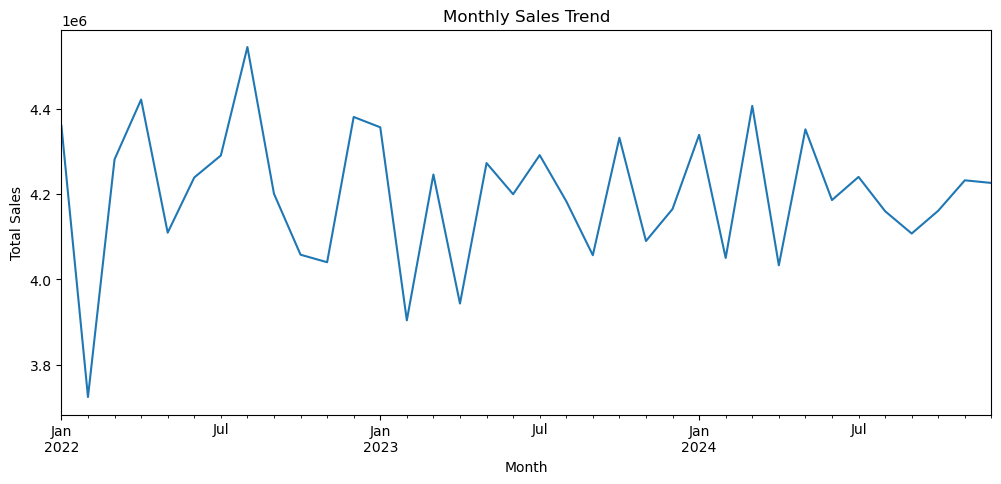

In [32]:
import matplotlib.pyplot as plt
monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

In [34]:
store_sales = sales.groupby("Store_ID")["Sales"].sum().sort_values(ascending=False)
store_sales.head()

Store_ID
STORE45    3240099.61
STORE47    3205103.96
STORE13    3195451.07
STORE11    3164958.46
STORE43    3164904.10
Name: Sales, dtype: float64

In [36]:
# 1. Top 10 Products by Sales
product_sales = sales.groupby("Product_ID")["Sales"].sum().sort_values(ascending=False)
product_sales.head()

Product_ID
PROD189    675860.32
PROD270    635942.90
PROD18     619413.35
PROD289    618738.14
PROD229    616724.01
Name: Sales, dtype: float64

In [38]:
# 2. Top 10 Stores by Profit
stores_profit = sales.groupby("Store_ID")["Sales"].sum().sort_values(ascending=False)
stores_profit.head()

Store_ID
STORE45    3240099.61
STORE47    3205103.96
STORE13    3195451.07
STORE11    3164958.46
STORE43    3164904.10
Name: Sales, dtype: float64

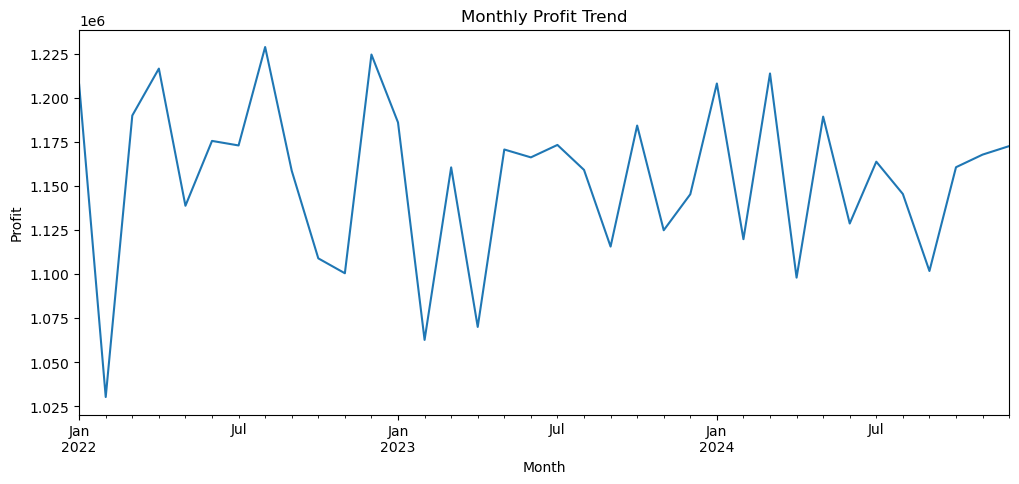

In [44]:
# 3. Profit Trend by Month
monthly_profit = sales.groupby(sales["Order_Date"].dt.to_period("M"))["Profit"].sum()

import matplotlib.pyplot as plt
monthly_profit.plot(figsize= (12,5))
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.show()

# Sales Analysis Project

 1. Import Libraries

 2. Load Dataset

 3. Data Exploration

 4. Data Cleaning

5. Sales Analysis

 6. Profit Analysis

 7. Store Analysis

 8. Product Analysis

 9. Conclusion

## Conclusion

- Analyzed 50,000 sales transactions.
- No missing values were found in the dataset.
- Monthly sales remained relatively stable between 2022 and 2024.
- Profit showed fluctuations across different months.
- Identified top-performing stores and products based on sales.
- Generated visualizations to understand business performance trends.

# Sales Analysis Project

## Project Overview
This project analyzes retail sales data using Python and Pandas.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

## Analysis Performed
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Monthly Sales Trend Analysis
- Monthly Profit Trend Analysis
- Store Performance Analysis
- Product Performance Analysis

## Dataset
Retail sales dataset containing 50,000 transactions.

## Key Insights
- Calculated total sales, cost, and profit.
- Identified top-performing stores and products.
- Analyzed sales and profit trends over time.